## Baidehi Basnet

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("deepfakedataset.csv")


df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0     20000 non-null  int64
 1   original_path  20000 non-null  str  
 2   id             20000 non-null  str  
 3   label          20000 non-null  int64
 4   label_str      20000 non-null  str  
 5   path           20000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 937.6 KB


In [3]:
df.describe()

,Unnamed: 0,label
count,20000.000000,20000.000000
mean,4999.500000,0.500000
std,2886.823503,0.500013
min,0.000000,0.000000
25%,2499.750000,0.000000
50%,4999.500000,0.500000
75%,7499.250000,1.000000
max,9999.000000,1.000000


In [4]:
df.isnull().sum()

df.duplicated().sum()



np.int64(0)

In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)

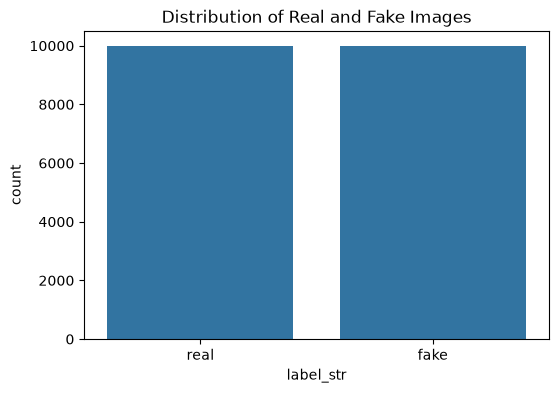

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label_str')

plt.title("Distribution of Real and Fake Images")

plt.show()

In [7]:
df['label_str'].value_counts(normalize=True)*100

label_str
real    50.0
fake    50.0
Name: proportion, dtype: float64

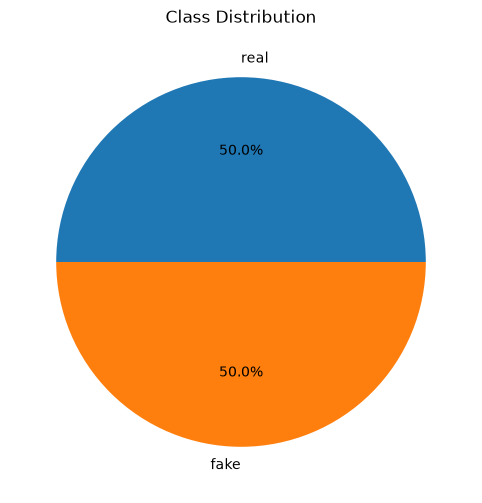

In [8]:
plt.figure(figsize=(6,6))

df['label_str'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Class Distribution")

plt.show()

In [9]:
df['id'].nunique()

20000

In [10]:
df['original_path'].head()

0    /kaggle/input/flickrfaceshq-dataset-nvidia-par...
1    /kaggle/input/flickrfaceshq-dataset-nvidia-par...
2    /kaggle/input/flickrfaceshq-dataset-nvidia-par...
3    /kaggle/input/flickrfaceshq-dataset-nvidia-par...
4    /kaggle/input/flickrfaceshq-dataset-nvidia-par...
Name: original_path, dtype: str

In [11]:
df['folder'] = df['path'].apply(lambda x: x.split('/')[1])

df.head()

,original_path,id,label,label_str,path,folder
0,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,18233,1,real,test/real/18233.jpg,real
1,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,54317,1,real,test/real/54317.jpg,real
2,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,40155,1,real,test/real/40155.jpg,real
3,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,12875,1,real,test/real/12875.jpg,real
4,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,52543,1,real,test/real/52543.jpg,real


## CNN model building

In [12]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [13]:
import pandas as pd

df = pd.read_csv("deepfakedataset.csv")

df.head()

,Unnamed: 0,original_path,id,label,label_str,path
0,0,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,18233,1,real,test/real/18233.jpg
1,1,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,54317,1,real,test/real/54317.jpg
2,2,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,40155,1,real,test/real/40155.jpg
3,3,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,12875,1,real,test/real/12875.jpg
4,4,/kaggle/input/flickrfaceshq-dataset-nvidia-par...,52543,1,real,test/real/52543.jpg


In [14]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

import seaborn as sns

import numpy as np

from tensorflow.keras.optimizers import Adam, RMSprop

from sklearn.metrics import accuracy_score

import pandas as pd

In [15]:
import os

DATASET_PATH = os.path.join(
    "archive",
    "real_vs_fake",
    "real-vs-fake"
)

print(DATASET_PATH)
print(os.path.exists(DATASET_PATH))

archive\real_vs_fake\real-vs-fake
True


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128,128)
BATCH_SIZE = 64

train_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    os.path.join(DATASET_PATH, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

valid_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    os.path.join(DATASET_PATH, "valid"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    os.path.join(DATASET_PATH, "test"),
    target_size=IMG_SIZE,
    batch_size=32,
    shuffle=False,
    class_mode="binary"
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [17]:
import os

print(os.listdir(os.path.join(DATASET_PATH, "train")))

['fake', 'real']


In [18]:
print(os.listdir(os.path.join(DATASET_PATH, "train", "real"))[:5])

['00000.jpg', '00002.jpg', '00003.jpg', '00006.jpg', '00009.jpg']


In [19]:
def build_model(optimizer):

    model = Sequential()

    model.add(Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)))
    model.add(MaxPooling2D())

    model.add(Conv2D(32, (3,3), activation='relu'))
    model.add(MaxPooling2D())

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D())

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

### Hyperparameter Configuration and Model Compilation

In [20]:

learning_rate = 0.001
epochs = 10
batch_size = 32

# Optimizer
optimizer = Adam(learning_rate=learning_rate)

model = build_model(optimizer)

c:\Users\user\anaconda3\envs\deepfake\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Train the CNN Model

In [22]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1278s 816ms/step - accuracy: 0.7657 - loss: 0.4828 - val_accuracy: 0.8527 - val_loss: 0.3484
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3455s 2s/step - accuracy: 0.8701 - loss: 0.3067 - val_accuracy: 0.9014 - val_loss: 0.2427
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2190s 1s/step - accuracy: 0.9092 - loss: 0.2237 - val_accuracy: 0.9201 - val_loss: 0.1987
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 944s 604ms/step - accuracy: 0.9312 - loss: 0.1746 - val_accuracy: 0.9308 - val_loss: 0.1759
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 240s 154ms/step - accuracy: 0.9442 - loss: 0.1419 - val_accuracy: 0.9429 - val_loss: 0.1530
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.9531 - loss: 0.1205 - val_accuracy: 0.9465 - val_loss: 0.1383
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.9607 - loss: 0.1007 - val_accuracy: 0.9403 - val_loss: 0.1667
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accur

## Hyperparameter Experimentation

### 1

In [21]:
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)
epochs = 10
batch_size = 32

### 2

In [22]:
learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)
epochs = 15
batch_size = 32

### 3

In [23]:
learning_rate = 0.0001
optimizer = RMSprop(learning_rate=learning_rate)
epochs = 20
batch_size = 32

### Training Accuracy 

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

### Training Loss Graph

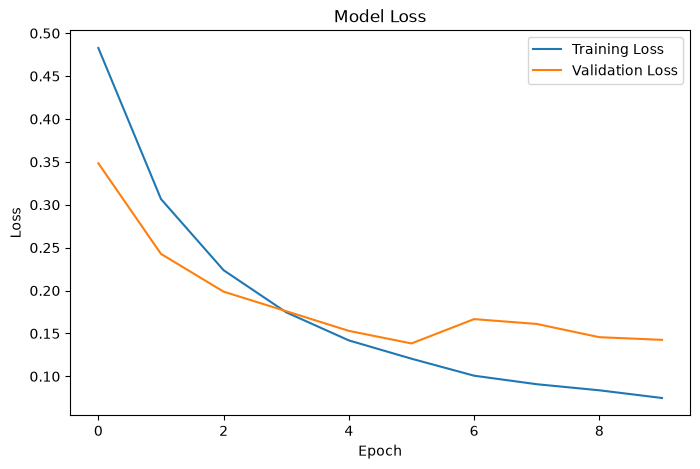

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Prediction

In [28]:
test_generator.reset()

y_pred = model.predict(test_generator)

y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = test_generator.classes

625/625 ━━━━━━━━━━━━━━━━━━━━ 248s 397ms/step


### Confusion Matrix

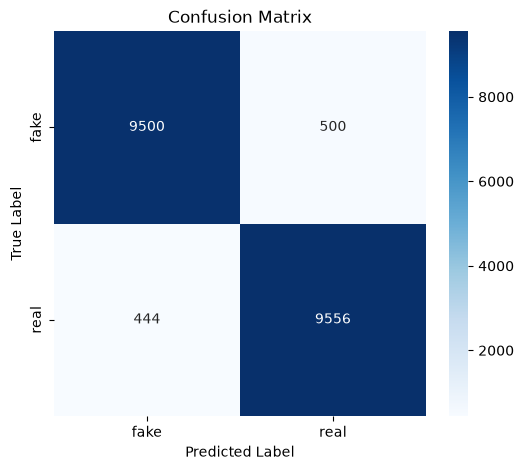

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### Precision

In [31]:
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.9503


### Recall

In [32]:
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.9556


### F1 Score

In [33]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9529


### Classification Report

In [34]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

        fake       0.96      0.95      0.95     10000
        real       0.95      0.96      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000

